In [1]:
import torch
from ultralytics import YOLO
from PIL import Image
import numpy as np

In [2]:
model = YOLO("best.pt")

torch.Size([1, 3, 640, 640])



0: 640x640 1 WBC, 14 RBCs, 133.8ms
Speed: 0.0ms preprocess, 133.8ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 640)


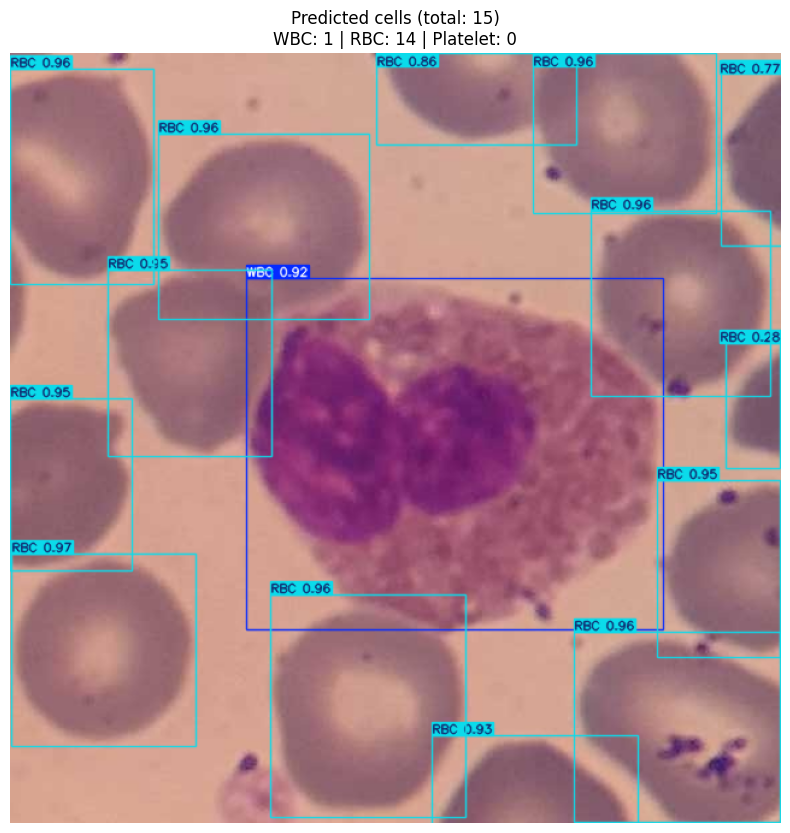

Total detections: 15
WBC: 1 | RBC: 14 | Platelet: 0


In [15]:
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path

test_img_path = Path("../data/test_img9.png")

test_img = Image.open(test_img_path)
test_img = test_img.resize(size=(640, 640))
tensor_test_img = torch.tensor(np.array(test_img)) / 255.0
tensor_test_img = tensor_test_img[:, :, :3]
tensor_test_img = tensor_test_img.permute((2, 1, 0)).unsqueeze(dim=0)
print(tensor_test_img.shape)


results = model(tensor_test_img)

result = results[0]
class_counts = Counter(result.boxes.cls.cpu().numpy().astype(int))
count_summary = " | ".join(
    f"{name}: {class_counts.get(class_id, 0)}"
    for class_id, name in result.names.items()
)

annotated_image = result.plot(labels=True, line_width=1, font_size=1.2, conf=True)
plt.figure(figsize=(14, 10))
plt.imshow(annotated_image[..., ::-1])
plt.axis("off")
plt.title(f"Predicted cells (total: {sum(class_counts.values())})\n{count_summary}")
plt.show()

print(f"Total detections: {sum(class_counts.values())}")
print(count_summary)